# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [1]:

import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()


   age        job  marital    education  default housing loan    contact month day_of_week  duration  campaign  pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y
0   56  housemaid  married     basic.4y       no      no   no  telephone   may         mon       261         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
1   57   services  married  high.school  unknown      no   no  telephone   may         mon       149         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
2   37   services  married  high.school       no     yes   no  telephone   may         mon       226         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
3   40     admin.  married     basic.6y       no      no   no  telephone   may         mon       151         1    999         0  nonexistent    

In [2]:

# Check for missing values and data types
df.info()
print()
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:

# Summary statistics
print(df.describe())
print()
print(df.describe(include='object'))


               age      duration      campaign         pdays      previous  emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000
mean      40.02406    258.285010      2.567593    962.475454      0.172963      0.081886       93.575664     -40.502600      3.621291   5167.035911
std       10.42125    259.279249      2.770014    186.910907      0.494901      1.570960        0.578840       4.628198      1.734447     72.251528
min       17.00000      0.000000      1.000000      0.000000      0.000000     -3.400000       92.201000     -50.800000      0.634000   4963.600000
25%       32.00000    102.000000      1.000000    999.000000      0.000000     -1.800000       93.075000     -42.700000      1.344000   5099.100000
50%       38.00000    180.000000      2.000000    999.000000      0.000000      1.100000       93.749000     -41

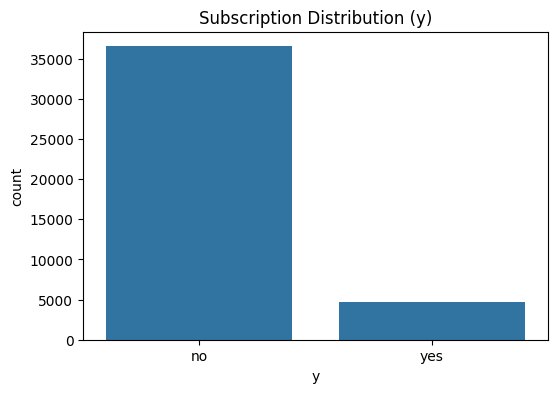

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [4]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
sns.countplot(x='y', data=df)
plt.title('Subscription Distribution (y)')
plt.show()

print(df['y'].value_counts(normalize=True))


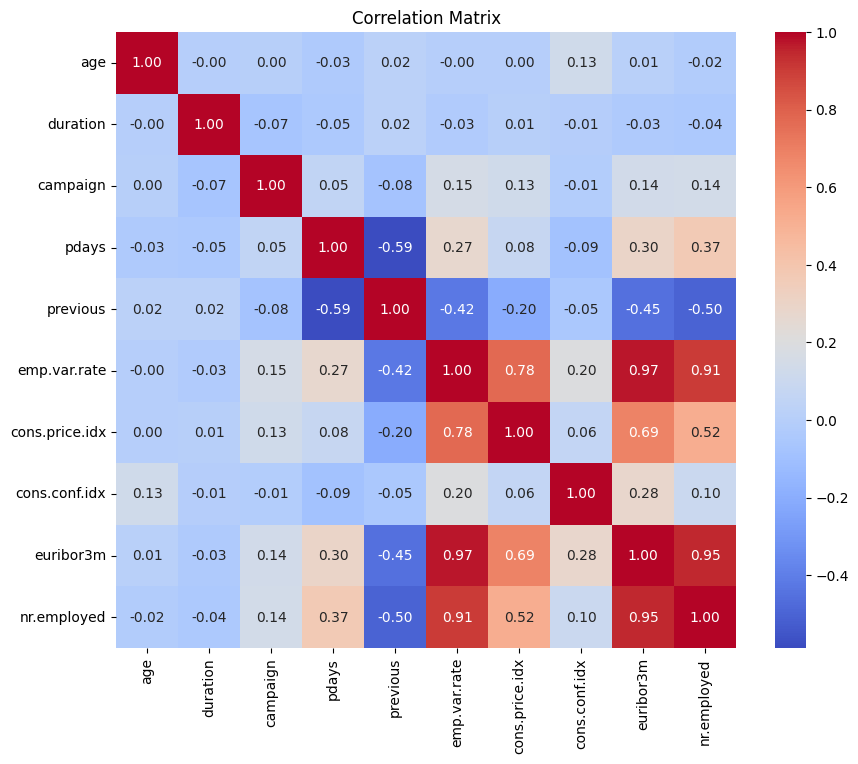

In [5]:

# Correlation matrix for numerical features
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- The dataset contains 41,188 records and 21 columns, with no missing values in any column.
- The target variable `y` is heavily imbalanced: about 88.7% of clients did not subscribe to a term deposit, while only 11.3% did.
- Numerical features like `emp.var.rate`, `euribor3m`, and `nr.employed` are strongly correlated with each other (all related to the broader economic climate at the time of contact), suggesting potential multicollinearity if used together in a model.
- Categorical features such as `job`, `education`, and `poutcome` (outcome of the previous campaign) may offer useful segmentation signals.
- Further preprocessing (encoding categoricals, handling the class imbalance, e.g. via SMOTE or class weighting) and feature engineering would be the next steps before building a predictive model.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
